# RAG 

- técnica amplamente utilizada na construção de chatbots
- A partir de um documento armazenado no banco de dados 
- Recuperar e gerar textos a partir de informações desse banco


### Projeto de Exemplo

- MentorCoffee: É um site desenvolvido em Django que promove mentorias, cursos e workshops para promoção de parceiros produtos e consumidores de café.

### Tecnologias 

1) Documento (.pdf)
2) site (HTML,CSS,JAVASCRIPT (Chart.JS),Django,SQLite,DjangoORM,Django Security,Django ADMIN )
3) LlamaIndex
4) Gradio: protótipo do chatbot
5) LangFlow: fluxo completo
6) HTML (Integração do CHATBOT)
7) Deploy  - PythonAnyWhere - (Vercel) - AWS
8) Python (linguagem)
9) HuggingFace

##### Vamos fazer um Hello RAG?

In [6]:
# coloque aqui o code
print("Hello RAG!")

Hello RAG!


In [7]:
# qual a versão do python que você está usando
! python --version

Python 3.13.3


In [8]:
# já instalou o ipykernel? Se não, instale com o comando: pip install ipykernel
print("Sim. Instalei o ipykernel, para usar o Jupyter no VS CODE!")

Sim. Instalei o ipykernel, para usar o Jupyter no VS CODE!


In [9]:
! python --version

Python 3.13.3


In [10]:
# se você usa o python 3.13.7 , qual versão do LlamaIndex você está usando? Se não tiver instalado, instale com o comando: pip install llama-index

In [11]:
# instalação do llama-index
! pip install -q llama-index==0.12.17 gradio==5.16.0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llama-index-embeddings-huggingface 0.8.0 requires llama-index-core<0.15,>=0.13.0, but you have llama-index-core 0.12.52.post1 which is incompatible.


O LlamaIndex é um framework de orquestração de dados (data framework) projetado para conectar bases de conhecimento privadas e não estruturadas a Modelos de Linguagem de Grande Porte (LLMs).

Ele atua como a infraestrutura central na arquitetura de RAG (Retrieval-Augmented Generation), resolvendo três limitações nativas dos LLMs: a janela de contexto limitada, a falta de acesso a dados privados/corporativos e a propensão a alucinações.

Dados Brutos -> (Ingestão/Loaders) [extração do texto e metadados]

In [12]:
from llama_index.core import SimpleDirectoryReader

Por que ele é tão útil?

Ele é inteligente o suficiente para ler vários tipos de arquivos sem que você precise escrever um código diferente para cada um:

    PDFs (.pdf)

    Documentos do Word (.docx)

    Apresentações de PowerPoint (.pptx)

    Arquivos de texto simples (.txt ou .md)

    Planilhas (.csv)

O nome dele é bastante literal: "Leitor Simples de Diretórios (Pastas)".

A função dele é abrir uma pasta do seu computador, ler os arquivos que estão lá dentro e transformar todo esse texto em um formato que a Inteligência Artificial consiga entender

In [13]:
documentos = SimpleDirectoryReader(input_dir='documentos')

In [14]:
documentos.input_files

[WindowsPath('c:/Users/User/Desktop/aula_rag_assincrona/mentorcoffee/documentos/mentor_coffee_atualizado.pdf')]

In [15]:
docs = documentos.load_data()

In [16]:
docs

[Document(id_='e79941c1-a22c-46b0-a4d9-6f5a0739e587', embedding=None, metadata={'page_label': '1', 'file_name': 'mentor_coffee_atualizado.pdf', 'file_path': 'c:\\Users\\User\\Desktop\\aula_rag_assincrona\\mentorcoffee\\documentos\\mentor_coffee_atualizado.pdf', 'file_type': 'application/pdf', 'file_size': 229748, 'creation_date': '2026-09-12', 'last_modified_date': '2026-09-12'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text='MentorCoffee – Mentoria e vendas de cafés especiais  \n  \nInformações gerais  \n  \nP: Quais produtos são vendidos no site da MentorCoffee?  \nR: A MentorCoffee é uma loja online especializada na venda de grãos de c

In [17]:
len(docs)

10

In [18]:
print(docs[0].get_metadata_str())

page_label: 1
file_name: mentor_coffee_atualizado.pdf
file_path: c:\Users\User\Desktop\aula_rag_assincrona\mentorcoffee\documentos\mentor_coffee_atualizado.pdf
file_type: application/pdf
file_size: 229748
creation_date: 2026-09-12
last_modified_date: 2026-09-12


In [19]:
print(docs[1].get_metadata_str())

page_label: 2
file_name: mentor_coffee_atualizado.pdf
file_path: c:\Users\User\Desktop\aula_rag_assincrona\mentorcoffee\documentos\mentor_coffee_atualizado.pdf
file_type: application/pdf
file_size: 229748
creation_date: 2026-09-12
last_modified_date: 2026-09-12


In [20]:
docs[0].__dict__

{'id_': 'e79941c1-a22c-46b0-a4d9-6f5a0739e587',
 'embedding': None,
 'metadata': {'page_label': '1',
  'file_name': 'mentor_coffee_atualizado.pdf',
  'file_path': 'c:\\Users\\User\\Desktop\\aula_rag_assincrona\\mentorcoffee\\documentos\\mentor_coffee_atualizado.pdf',
  'file_type': 'application/pdf',
  'file_size': 229748,
  'creation_date': '2026-09-12',
  'last_modified_date': '2026-09-12'},
 'excluded_embed_metadata_keys': ['file_name',
  'file_type',
  'file_size',
  'creation_date',
  'last_modified_date',
  'last_accessed_date'],
 'excluded_llm_metadata_keys': ['file_name',
  'file_type',
  'file_size',
  'creation_date',
  'last_modified_date',
  'last_accessed_date'],
 'relationships': {},
 'metadata_template': '{key}: {value}',
 'metadata_separator': '\n',
 'text_resource': MediaResource(embeddings=None, data=None, text='MentorCoffee – Mentoria e vendas de cafés especiais  \n  \nInformações gerais  \n  \nP: Quais produtos são vendidos no site da MentorCoffee?  \nR: A MentorCof

# Aula 2 - Organizando os documentos em partes menores

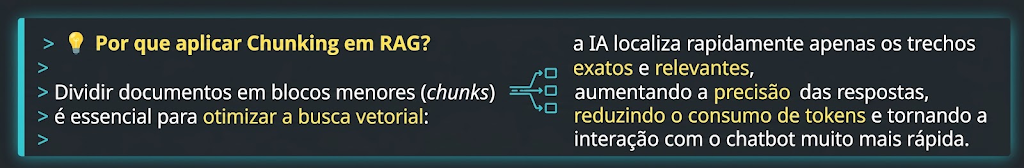

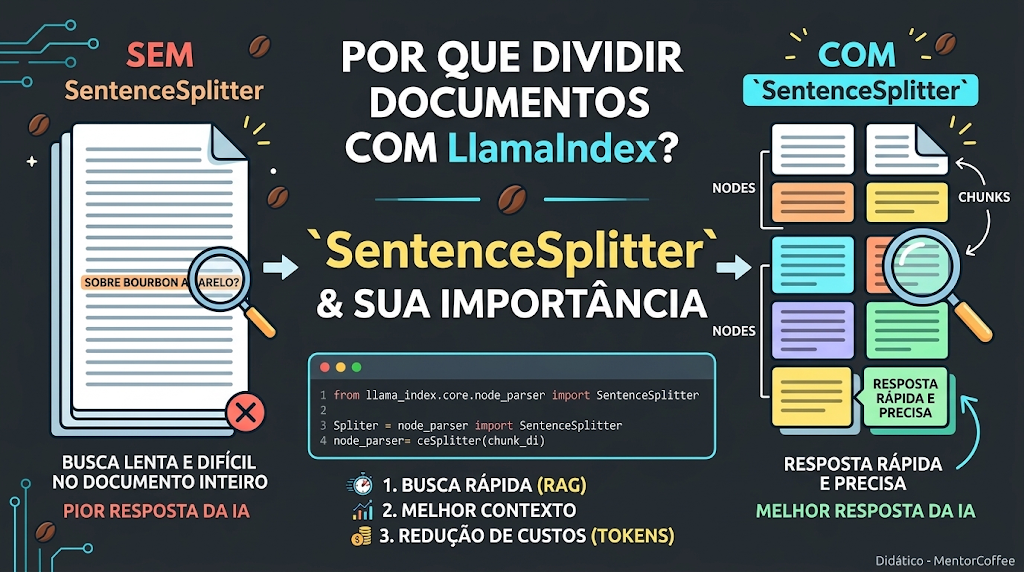

##### llama_index.core.node_parser: Módulo do LlamaIndex focado em transformar documentos em Nodes (unidades fundamentais de informação no LlamaIndex)

In [32]:
from llama_index.core.node_parser import SentenceSplitter

#### ⚙️ Configurando o Divisor de Texto (`SentenceSplitter`)

```python
node_parser = SentenceSplitter(chunk_size=1200)
```

> ✂️ **O que este código faz:** Instancia o fatiador para dividir os documentos em blocos (*nodes/chunks*) de até **1.200 caracteres** cada.
> 🎯 **Objetivo:** Garante que o texto seja quebrado no tamanho ideal para ser armazenado e localizado rapidamente na busca do chatbot.

In [22]:
node_parser = SentenceSplitter(chunk_size=1200)

### 🧩 Gerando os Blocos de Texto (`Nodes`)

```python
nodes = node_parser.get_nodes_from_documents(docs, show_progress=True)
```

> ⚙️ **O que este código faz:** Executa a divisão dos documentos (`docs`) nos blocos menores pré-configurados e exibe uma barra de progresso no terminal.
> 🎯 **Objetivo:** Transforma arquivos extensos em uma lista de pedaços (*nodes*) estruturados, prontos para serem salvos no banco de dados do chatbot.


In [33]:
nodes  = node_parser.get_nodes_from_documents(docs, show_progress=True)

Parsing nodes:   0%|          | 0/10 [00:00<?, ?it/s]

Parsing nodes: 100%|██████████| 10/10 [00:00<00:00, 139.27it/s]


### 📏 Conferindo a Quantidade de Blocos Gerados

```python
len(nodes)
```

> ⚙️ **O que este código faz:** Retorna o número total de pedaços (*nodes*) criados após a divisão do documento original.
> 🎯 **Objetivo:** Permite verificar rapidamente em quantos blocos o arquivo foi fatiado e validar o resultado do processo de *chunking*.

In [30]:
# conferindo os blocos gerados
len(nodes)

10

In [34]:
print(nodes[0])

Node ID: b96082be-244b-47d9-b315-e57eda51a614
Text: MentorCoffee – Mentoria e vendas de cafés especiais
Informações gerais      P: Quais produtos são vendidos no site da
MentorCoffee?   R: A MentorCoffee é uma loja online especializada na
venda de grãos de cafés especiais,  oferecendo grãos torrados,
provenientes de fazendas seleci onadas da região de   Brazlândia, a
produção é realizada no ...


In [35]:
print(nodes[9])

Node ID: 23b893cc-eb94-41d3-b232-831a274478d3
Text: R: Recomendamos armazenar os grãos em um rec ipiente hermético,
longe da umidade  e calor. Evite guardar o café na geladeira, pois a
umidade e as variações de temperatura  podem prejudicar o sabor e o
aroma.      P: Qual é a validade dos cafés da MentorCoffee?   R:
Nossos cafés são enviados recém -torrados pa ra garantir frescor. Para
uma  exper...


# Aula 3 - Banco de Dados

### 🗄️ Criando o Banco de Dados Vetorial (ChromaDB)

> ⚙️ **O que este passo faz:** Armazena os blocos de texto (*nodes*) em um banco de dados local chamado **ChromaDB**, transformando informações em vetores de busca.
> 🎯 **Objetivo:** Permitir que o chatbot consulte rapidamente as informações sobre os cafés da MentorCoffee com máxima eficiência e otimização.

In [41]:
%%capture
! pip install llama-index-embeddings-huggingface

In [39]:
! pip install -q -U huggingface-hub llama-index-embeddings-huggingface

In [36]:
# Instalando o pacote para utilizar modelos de embedding da Hugging Face com o LlamaIndex
! pip install -q llama-index-embeddings-huggingface

In [28]:
# Importando a classe HuggingFaceEmbedding para utilizar modelos de embedding da Hugging Face no LlamaIndex
from llama_index.embeddings.huggingface import HuggingFaceEmbedding